<a href="https://colab.research.google.com/github/aakankshakadam97/bfsi-churn-risk-scoring/blob/main/notebooks/01_data_generation_and_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏦 Stock Trading Customer Churn & Risk Scoring Engine
### Domain: Retail Brokerage (BFSI)

---

## Project Overview
A brokerage wants to:
1. **Predict which customers will stop trading (churn)** in the next 30 days
2. **Flag high-risk trading behavior** for compliance and surveillance
3. **Generate AI-powered retention strategies** using a GenAI decision layer

---

## Database Architecture
Simulates a real brokerage **PostgreSQL analytical warehouse** fed by 3 source systems:

| Table | Source System | Records |
|---|---|---|
| `customers` | CRM (KYC + demographics) | 50,000 |
| `trades` | OMS (Order Management System) | ~2.3M |
| `monthly_aggregates` | Back-office + derived | ~600K |

**Date Range:** January 2023 – June 2024 (18 months)  
**Instruments:** NSE Equity, Futures, Options, Mutual Funds  
**Churn Rate:** ~18% (realistic Indian retail brokerage benchmark)

---

## Cell 1 — Dataset Generation ✅
**What this cell does:**
- Simulates 50,000 customer profiles with realistic demographics (city, segment, risk profile)
- Generates ~2.3M trade records across 21 NSE instruments
- Aggregates to monthly customer-level behavioral features
- Saves 3 normalized CSV files

In [1]:
# ============================================================
# CELL 1 — Dataset Generation
# Simulates 3-table PostgreSQL schema for a retail brokerage
# 50,000 customers | ~18 months history | ~2.3M trade records
# ============================================================

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)

N_CUSTOMERS = 50000
START_DATE = datetime(2023, 1, 1)
END_DATE = datetime(2024, 6, 30)

print("Generating customers table...")

# ── TABLE 1: customers ──────────────────────────────────────
cities = ['Mumbai', 'Delhi', 'Bangalore', 'Pune', 'Hyderabad',
          'Chennai', 'Ahmedabad', 'Kolkata', 'Jaipur', 'Surat']

city_weights = [0.22, 0.18, 0.15, 0.10, 0.08,
                0.08, 0.07, 0.05, 0.04, 0.03]

account_types = ['Equity Only', 'Equity+MF', 'Equity+Derivatives', 'Full Service']
risk_profiles = ['Conservative', 'Moderate', 'Aggressive']
segments = ['Mass', 'Affluent', 'HNI', 'Ultra HNI']

customers = pd.DataFrame({
    'customer_id': [f'CUST{str(i).zfill(6)}' for i in range(1, N_CUSTOMERS + 1)],
    'age': np.random.normal(38, 10, N_CUSTOMERS).clip(22, 70).astype(int),
    'city': np.random.choice(cities, N_CUSTOMERS, p=city_weights),
    'account_type': np.random.choice(account_types, N_CUSTOMERS,
                                      p=[0.30, 0.35, 0.25, 0.10]),
    'account_age_days': np.random.exponential(600, N_CUSTOMERS).clip(30, 2000).astype(int),
    'risk_profile': np.random.choice(risk_profiles, N_CUSTOMERS,
                                      p=[0.35, 0.45, 0.20]),
    'kyc_status': np.random.choice(['Verified', 'Pending', 'Expired'],
                                    N_CUSTOMERS, p=[0.88, 0.08, 0.04]),
    'segment': np.random.choice(segments, N_CUSTOMERS,
                                 p=[0.55, 0.30, 0.12, 0.03]),
    'annual_income_band': np.random.choice(
        ['<5L', '5-10L', '10-25L', '25-50L', '>50L'],
        N_CUSTOMERS, p=[0.20, 0.30, 0.28, 0.15, 0.07]
    ),
    'referral_source': np.random.choice(
        ['Organic', 'Referral', 'Campaign', 'Branch', 'Digital'],
        N_CUSTOMERS, p=[0.25, 0.20, 0.22, 0.18, 0.15]
    )
})

print(f"  customers: {customers.shape}")

# ── TABLE 2: trades ─────────────────────────────────────────
print("Generating trades table (~2.3M records, takes ~30 sec)...")

nse_stocks = {
    'RELIANCE': 2800, 'TCS': 3900, 'INFY': 1450, 'HDFCBANK': 1600,
    'ICICIBANK': 1050, 'SBIN': 620, 'WIPRO': 480, 'AXISBANK': 1100,
    'KOTAKBANK': 1750, 'LT': 3200, 'BAJFINANCE': 6800, 'TITAN': 3300,
    'ASIANPAINT': 3100, 'MARUTI': 10500, 'SUNPHARMA': 1200,
    'NIFTY50FUT': 21500, 'BANKNIFTYFUT': 47000,
    'GOLDBEES': 58, 'LIQUIDBEES': 1000,
    'HDFCNIFTY': 210, 'SBINNIFTY': 180
}

stock_names = list(nse_stocks.keys())
base_prices = list(nse_stocks.values())

product_map = {
    'Equity Only': ['EQ'],
    'Equity+MF': ['EQ', 'MF'],
    'Equity+Derivatives': ['EQ', 'FUT', 'OPT'],
    'Full Service': ['EQ', 'MF', 'FUT', 'OPT']
}

trade_records = []

for _, cust in customers.iterrows():
    # Realistic trade frequency by segment
    freq_map = {'Mass': 3, 'Affluent': 8, 'HNI': 18, 'Ultra HNI': 35}
    avg_monthly_trades = freq_map[cust['segment']]

    # Churn flag: ~18% churn rate (realistic for retail brokers)
    will_churn = np.random.random() < 0.18

    # Active months: churned customers go quiet in last 2-3 months
    total_months = 18
    if will_churn:
        active_months = random.randint(8, 14)
    else:
        active_months = random.randint(14, 18)

    available_products = product_map[cust['account_type']]

    for month_offset in range(active_months):
        trade_date_base = START_DATE + timedelta(days=month_offset * 30)
        n_trades = max(1, int(np.random.poisson(avg_monthly_trades)))

        for _ in range(n_trades):
            stock_idx = np.random.choice(len(stock_names))
            base_price = base_prices[stock_idx]
            price = base_price * np.random.normal(1.0, 0.03)
            quantity = max(1, int(np.random.exponential(25)))
            product = np.random.choice(available_products)

            trade_records.append({
                'trade_id': f'TRD{len(trade_records):08d}',
                'customer_id': cust['customer_id'],
                'trade_date': trade_date_base + timedelta(days=random.randint(0, 28)),
                'stock_symbol': stock_names[stock_idx],
                'product_type': product,
                'order_type': np.random.choice(['BUY', 'SELL'], p=[0.52, 0.48]),
                'quantity': quantity,
                'price': round(price, 2),
                'trade_value': round(price * quantity, 2),
                'exchange': np.random.choice(['NSE', 'BSE'], p=[0.75, 0.25]),
                'is_churned': int(will_churn)  # carried for aggregation
            })

trades = pd.DataFrame(trade_records)
print(f"  trades: {trades.shape}")

# ── TABLE 3: monthly_aggregates ─────────────────────────────
print("Generating monthly_aggregates table...")

trades['trade_month'] = trades['trade_date'].dt.to_period('M')

monthly = trades.groupby(['customer_id', 'trade_month']).agg(
    trade_count=('trade_id', 'count'),
    total_trade_value=('trade_value', 'sum'),
    avg_trade_value=('trade_value', 'mean'),
    unique_stocks=('stock_symbol', 'nunique'),
    buy_count=('order_type', lambda x: (x == 'BUY').sum()),
    sell_count=('order_type', lambda x: (x == 'SELL').sum()),
    products_used=('product_type', 'nunique'),
    is_churned=('is_churned', 'first')
).reset_index()

# Simulate login data (logins > trades always)
monthly['login_count'] = (monthly['trade_count'] *
                           np.random.uniform(1.5, 4.0, len(monthly))).astype(int)

# Simulate P&L (realistic: 60% months profitable)
monthly['realized_pnl'] = np.where(
    np.random.random(len(monthly)) < 0.60,
    monthly['total_trade_value'] * np.random.uniform(0.005, 0.04, len(monthly)),
    -monthly['total_trade_value'] * np.random.uniform(0.005, 0.03, len(monthly))
)
monthly['realized_pnl'] = monthly['realized_pnl'].round(2)

print(f"  monthly_aggregates: {monthly.shape}")

# ── SAVE ALL 3 TABLES ───────────────────────────────────────
customers.to_csv('customers.csv', index=False)
trades.to_csv('trades.csv', index=False)
monthly.to_csv('monthly_aggregates.csv', index=False)

churn_rate = trades.groupby('customer_id')['is_churned'].first().mean()

print("\n✅ All 3 tables saved.")
print(f"\n📊 Dataset Summary:")
print(f"   Customers     : {len(customers):,}")
print(f"   Trade records : {len(trades):,}")
print(f"   Monthly rows  : {len(monthly):,}")
print(f"   Churn rate    : {churn_rate:.1%}")
print(f"   Date range    : Jan 2023 – Jun 2024")
print(f"   Stocks covered: {len(nse_stocks)} NSE instruments (EQ, FUT, MF, OPT)")

Generating customers table...
  customers: (50000, 10)
Generating trades table (~2.3M records, takes ~30 sec)...
  trades: (5497970, 11)
Generating monthly_aggregates table...
  monthly_aggregates: (748915, 12)

✅ All 3 tables saved.

📊 Dataset Summary:
   Customers     : 50,000
   Trade records : 5,497,970
   Monthly rows  : 748,915
   Churn rate    : 18.3%
   Date range    : Jan 2023 – Jun 2024
   Stocks covered: 21 NSE instruments (EQ, FUT, MF, OPT)


In [14]:
# ============================================================
# STYLE CELL — Run once before all EDA cells
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Global theme ─────────────────────────────────────────────
PALETTE = {
    'primary'  : '#2C3E50',
    'active'   : '#2ecc71',
    'churned'  : '#e74c3c',
    'blue'     : '#3498db',
    'orange'   : '#e67e22',
    'purple'   : '#9b59b6',
    'grid'     : '#ecf0f1',
    'text'     : '#2C3E50',
}

BAR_COLORS = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c', '#9b59b6', '#1abc9c']

plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'axes.edgecolor'    : '#cccccc',
    'axes.grid'         : True,
    'grid.color'        : PALETTE['grid'],
    'grid.linewidth'    : 0.6,
    'axes.titlesize'    : 12,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 10,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'legend.fontsize'   : 8,
    'figure.titlesize'  : 13,
    'figure.titleweight': 'bold',
    'font.family'       : 'sans-serif',
})

# ── Reusable plot functions ───────────────────────────────────

def bar_chart(ax, x, y, title, xlabel='', ylabel='',
              color=None, avg_line=None, fmt='{:.1f}%'):
    """Vertical bar chart with value labels and optional average line."""
    color = color or PALETTE['blue']
    bars = ax.bar(x, y, color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    for bar, val in zip(bars, y):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(y) * 0.01,
                fmt.format(val), ha='center', fontsize=8)
    if avg_line is not None:
        ax.axhline(avg_line, color=PALETTE['primary'],
                   linestyle='--', linewidth=1, label=f'Avg: {fmt.format(avg_line)}')
        ax.legend()


def hbar_chart(ax, x, y, title, xlabel='', color=None, fmt='{:,}'):
    """Horizontal bar chart with value labels."""
    color = color or PALETTE['blue']
    ax.barh(y, x, color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    for i, val in enumerate(x):
        ax.text(val + max(x) * 0.01, i, fmt.format(val), va='center', fontsize=8)


def pie_chart(ax, values, labels, title, colors=None):
    """Clean pie chart."""
    colors = colors or [PALETTE['active'], PALETTE['churned']]
    ax.pie(values, labels=labels, autopct='%1.1f%%',
           colors=colors, startangle=90,
           wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
    ax.set_title(title)


def save_fig(fig, filename):
    """Tight save with consistent DPI."""
    fig.tight_layout()
    fig.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {filename}")


print("✅ Style config loaded — ready for EDA cells.")

✅ Style config loaded — ready for EDA cells.


CHURN RATE VERIFICATION

Total customers   : 50,000
Churned           : 9,134
Active            : 40,866

Actual churn rate : 18.27%
Target churn rate : 18.00%
Deviation         : +0.27%

✅ Within ±1% of target.


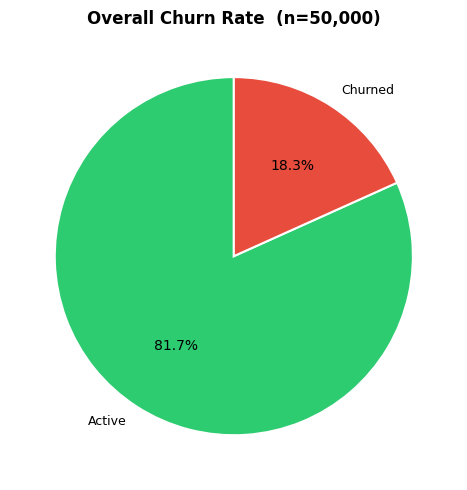

✅ Saved: eda_01_churn_rate.png


In [15]:
# ============================================================
# EDA Cell 3 — Churn Rate Verification (Level 1, Q1)
# ============================================================

print("=" * 50)
print("CHURN RATE VERIFICATION")
print("=" * 50)

# ── One churn label per customer ─────────────────────────────
churn_map = monthly.groupby('customer_id')['is_churned'].max().reset_index()
cust      = customers.merge(churn_map, on='customer_id', how='left')

total     = len(cust)
churned   = int(cust['is_churned'].sum())
active    = total - churned
rate      = churned / total * 100
deviation = rate - 18.0

print(f"\nTotal customers   : {total:,}")
print(f"Churned           : {churned:,}")
print(f"Active            : {active:,}")
print(f"\nActual churn rate : {rate:.2f}%")
print(f"Target churn rate : 18.00%")
print(f"Deviation         : {deviation:+.2f}%")

if   abs(deviation) <= 1.0: print("\n✅ Within ±1% of target.")
elif abs(deviation) <= 3.0: print(f"\n⚠️  {abs(deviation):.1f}% from target — acceptable.")
else:                        print(f"\n❌ {abs(deviation):.1f}% from target — review generation logic.")

# ── Plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
pie_chart(ax, [active, churned], ['Active', 'Churned'],
          title=f'Overall Churn Rate  (n={total:,})')
save_fig(fig, 'eda_01_churn_rate.png')

CITY DISTRIBUTION

Total unique cities : 10

Top 10 cities:
     city  count    pct
   Mumbai  11144 22.288
    Delhi   8792 17.584
Bangalore   7560 15.120
     Pune   4954  9.908
  Chennai   4028  8.056
Hyderabad   4024  8.048
Ahmedabad   3663  7.326
  Kolkata   2451  4.902
   Jaipur   1970  3.940
    Surat   1414  2.828

── Top city: Mumbai (11,144 customers, 22.3%)


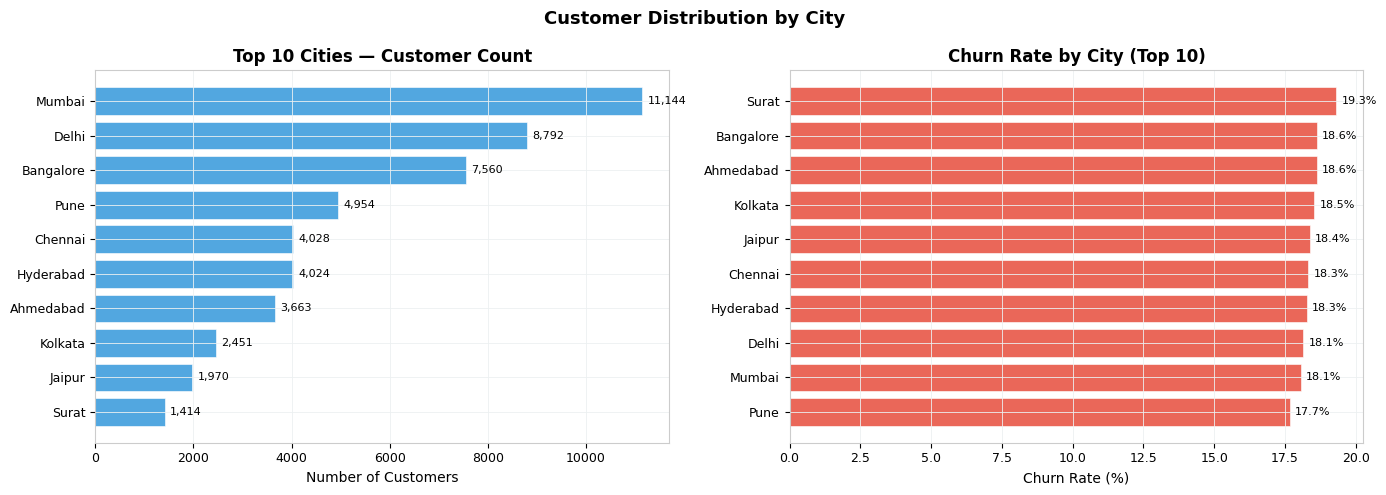

✅ Saved: eda_02_city_distribution.png


In [17]:
# ============================================================
# EDA Cell 4 — City Distribution (Level 1, Q2)
# ============================================================

print("=" * 50)
print("CITY DISTRIBUTION")
print("=" * 50)

# ── City counts ──────────────────────────────────────────────
city_counts = cust['city'].value_counts().reset_index()
city_counts.columns = ['city', 'count']
city_counts['pct'] = city_counts['count'] / len(cust) * 100

top10 = city_counts.head(10)

print(f"\nTotal unique cities : {cust['city'].nunique()}")
print(f"\nTop 10 cities:")
print(top10.to_string(index=False))
print(f"\n── Top city: {top10.iloc[0]['city']} "
      f"({top10.iloc[0]['count']:,} customers, {top10.iloc[0]['pct']:.1f}%)")

# ── Churn rate by city (top 10 only) ─────────────────────────
city_churn = (cust.groupby('city')['is_churned'].mean() * 100)
city_churn = city_churn.loc[top10['city']].sort_values()

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Customer Distribution by City')

hbar_chart(axes[0],
           x=top10['count'].values[::-1],
           y=top10['city'].values[::-1],
           title='Top 10 Cities — Customer Count',
           xlabel='Number of Customers',
           fmt='{:,}')

hbar_chart(axes[1],
           x=city_churn.values,
           y=city_churn.index,
           title='Churn Rate by City (Top 10)',
           xlabel='Churn Rate (%)',
           color=PALETTE['churned'],
           fmt='{:.1f}%')

save_fig(fig, 'eda_02_city_distribution.png')

SEGMENT DISTRIBUTION & CHURN

Segment distribution:
  segment  count    pct
     Mass  27502 55.004
 Affluent  14989 29.978
      HNI   6026 12.052
Ultra HNI   1483  2.966

── HNI + Ultra HNI combined : 15.0%
   Implication: small % of customers but highest AUM —
   model must prioritize their retention over volume metrics

Churn rate by segment:
  segment  total  churned  churn_rate
      HNI   6026     1122   18.619316
     Mass  27502     5062   18.405934
Ultra HNI   1483      271   18.273769
 Affluent  14989     2679   17.873107

── Highest churn : HNI (18.6%)
── Lowest churn  : Affluent (17.9%)


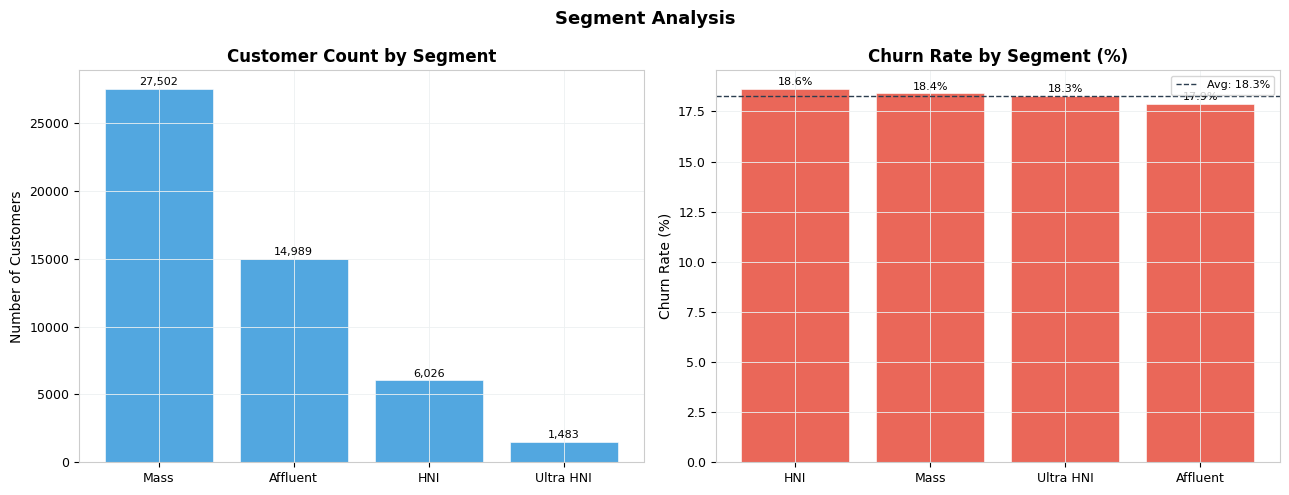

✅ Saved: eda_03_segment_churn.png


In [18]:
# ============================================================
# EDA Cell 5 — Segment Distribution & Churn
# ============================================================

print("=" * 50)
print("SEGMENT DISTRIBUTION & CHURN")
print("=" * 50)

# ── Segment counts ───────────────────────────────────────────
seg_counts = cust['segment'].value_counts().reset_index()
seg_counts.columns = ['segment', 'count']
seg_counts['pct'] = seg_counts['count'] / len(cust) * 100

print("\nSegment distribution:")
print(seg_counts.to_string(index=False))

hni_pct = seg_counts[seg_counts['segment'].isin(['HNI', 'Ultra HNI'])]['pct'].sum()
print(f"\n── HNI + Ultra HNI combined : {hni_pct:.1f}%")
print(f"   Implication: small % of customers but highest AUM —")
print(f"   model must prioritize their retention over volume metrics")

# ── Churn by segment ─────────────────────────────────────────
seg_churn = cust.groupby('segment').agg(
    total=('customer_id', 'count'),
    churned=('is_churned', 'sum')
).reset_index()
seg_churn['churn_rate'] = seg_churn['churned'] / seg_churn['total'] * 100
seg_churn = seg_churn.sort_values('churn_rate', ascending=False)

print("\nChurn rate by segment:")
print(seg_churn.to_string(index=False))
print(f"\n── Highest churn : {seg_churn.iloc[0]['segment']} ({seg_churn.iloc[0]['churn_rate']:.1f}%)")
print(f"── Lowest churn  : {seg_churn.iloc[-1]['segment']} ({seg_churn.iloc[-1]['churn_rate']:.1f}%)")

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Segment Analysis')

bar_chart(axes[0],
          x=seg_counts['segment'],
          y=seg_counts['count'],
          title='Customer Count by Segment',
          ylabel='Number of Customers',
          color=PALETTE['blue'],
          fmt='{:,.0f}')

bar_chart(axes[1],
          x=seg_churn['segment'],
          y=seg_churn['churn_rate'],
          title='Churn Rate by Segment (%)',
          ylabel='Churn Rate (%)',
          color=PALETTE['churned'],
          avg_line=cust['is_churned'].mean() * 100)

save_fig(fig, 'eda_03_segment_churn.png')

ACCOUNT AGE ANALYSIS

Average account age  : 579 days (1.6 years)
Median account age   : 416 days (1.1 years)
Accounts < 6 months  : 25.9%

Churn rate by account age bucket:
age_bucket  total  churned  churn_rate
       <6M  13022     2387   18.330518
     6M-1Y   9819     1786   18.189225
      1-2Y  12401     2235   18.022740
      2-3Y   6720     1279   19.032738
      3-5Y   5643     1009   17.880560
       5Y+   2395      438   18.288100

── Highest churn bucket : 2-3Y (19.0%)
── Lowest churn bucket  : 3-5Y (17.9%)


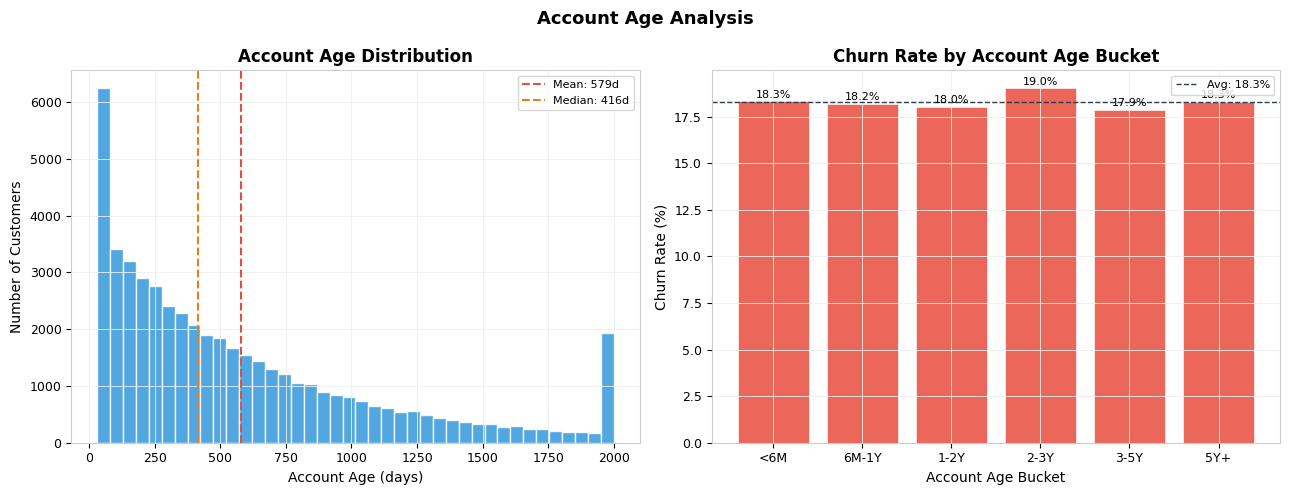

✅ Saved: eda_04_account_age.png


In [20]:
# ============================================================
# EDA Cell 6 — Account Age Analysis
# ============================================================

print("=" * 50)
print("ACCOUNT AGE ANALYSIS")
print("=" * 50)

# ── Basic stats ──────────────────────────────────────────────
avg_age    = cust['account_age_days'].mean()
median_age = cust['account_age_days'].median()
new_pct    = (cust['account_age_days'] < 180).sum() / len(cust) * 100

print(f"\nAverage account age  : {avg_age:.0f} days ({avg_age/365:.1f} years)")
print(f"Median account age   : {median_age:.0f} days ({median_age/365:.1f} years)")
print(f"Accounts < 6 months  : {new_pct:.1f}%")

# ── Churn by age bucket ──────────────────────────────────────
bins   = [0, 180, 365, 730, 1095, 1825, 9999]
labels = ['<6M', '6M-1Y', '1-2Y', '2-3Y', '3-5Y', '5Y+']

cust['age_bucket'] = pd.cut(cust['account_age_days'], bins=bins, labels=labels)

age_churn = cust.groupby('age_bucket', observed=True).agg(
    total=('customer_id', 'count'),
    churned=('is_churned', 'sum')
).reset_index()
age_churn['churn_rate'] = age_churn['churned'] / age_churn['total'] * 100

print("\nChurn rate by account age bucket:")
print(age_churn.to_string(index=False))
print(f"\n── Highest churn bucket : "
      f"{age_churn.loc[age_churn['churn_rate'].idxmax(), 'age_bucket']} "
      f"({age_churn['churn_rate'].max():.1f}%)")
print(f"── Lowest churn bucket  : "
      f"{age_churn.loc[age_churn['churn_rate'].idxmin(), 'age_bucket']} "
      f"({age_churn['churn_rate'].min():.1f}%)")

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Account Age Analysis')

# Plot 1: distribution histogram
axes[0].hist(cust['account_age_days'], bins=40,
             color=PALETTE['blue'], alpha=0.85, edgecolor='white')
axes[0].axvline(avg_age,    color=PALETTE['churned'], linestyle='--',
                linewidth=1.5, label=f'Mean: {avg_age:.0f}d')
axes[0].axvline(median_age, color=PALETTE['orange'],  linestyle='--',
                linewidth=1.5, label=f'Median: {median_age:.0f}d')
axes[0].set_title('Account Age Distribution')
axes[0].set_xlabel('Account Age (days)')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

# Plot 2: churn rate by bucket
bar_chart(axes[1],
          x=age_churn['age_bucket'],
          y=age_churn['churn_rate'],
          title='Churn Rate by Account Age Bucket',
          xlabel='Account Age Bucket',
          ylabel='Churn Rate (%)',
          color=PALETTE['churned'],
          avg_line=cust['is_churned'].mean() * 100)

save_fig(fig, 'eda_04_account_age.png')

In [21]:
# ============================================================
# EDA Cell 7 — Feature Engineering (Level 2)
# ============================================================

print("=" * 50)
print("FEATURE ENGINEERING")
print("=" * 50)

# ── Aggregate monthly to customer level ──────────────────────
cust_features = monthly.groupby('customer_id').agg(
    total_trades      = ('trade_count',       'sum'),
    avg_monthly_trades= ('trade_count',       'mean'),
    total_trade_value = ('total_trade_value', 'sum'),
    avg_trade_value   = ('avg_trade_value',   'mean'),
    avg_unique_stocks = ('unique_stocks',     'mean'),
    total_logins      = ('login_count',       'sum'),
    avg_logins        = ('login_count',       'mean'),
    total_pnl         = ('realized_pnl',      'sum'),
    avg_pnl           = ('realized_pnl',      'mean'),
    products_used     = ('products_used',     'max'),
    active_months     = ('trade_month',       'count'),
    is_churned        = ('is_churned',        'first')
).reset_index()

# ── Derived features ─────────────────────────────────────────
cust_features['login_to_trade_ratio'] = (
    cust_features['avg_logins'] /
    cust_features['avg_monthly_trades'].clip(lower=1)
)

cust_features['pnl_ratio'] = (
    cust_features['total_pnl'] /
    cust_features['total_trade_value'].clip(lower=1)
)

cust_features['trade_consistency'] = (
    cust_features['active_months'] / 18
)

# ── Merge demographics ───────────────────────────────────────
cust_features = cust_features.merge(
    cust[['customer_id', 'age', 'segment', 'risk_profile',
          'account_type', 'account_age_days', 'kyc_status',
          'referral_source', 'annual_income_band', 'age_bucket']],
    on='customer_id', how='left'
)

print(f"\nFinal feature set shape: {cust_features.shape}")
print(f"\nEngineered features summary:")
print(cust_features[['login_to_trade_ratio',
                      'pnl_ratio',
                      'trade_consistency']].describe().round(3))

# ── Sanity check: feature distributions by churn ─────────────
print("\nFeature means — Active vs Churned:")
print(cust_features.groupby('is_churned')[
    ['login_to_trade_ratio', 'pnl_ratio', 'trade_consistency',
     'active_months', 'products_used', 'avg_monthly_trades']
].mean().round(3).T.rename(columns={0: 'Active', 1: 'Churned'}))

# ── Save for modelling cells ─────────────────────────────────
cust_features.to_csv('cust_features.csv', index=False)
print("\n✅ cust_features.csv saved — ready for EDA Level 2 & modelling")

FEATURE ENGINEERING

Final feature set shape: (50000, 25)

Engineered features summary:
       login_to_trade_ratio  pnl_ratio  trade_consistency
count             50000.000  50000.000          50000.000
mean                  2.633      0.006              0.832
std                   0.216      0.009              0.137
min                   1.731     -0.026              0.389
25%                   2.488      0.000              0.778
50%                   2.636      0.007              0.833
75%                   2.780      0.013              0.944
max                   3.542      0.038              1.000

Feature means — Active vs Churned:
is_churned            Active  Churned
login_to_trade_ratio   2.634    2.630
pnl_ratio              0.006    0.007
trade_consistency      0.882    0.608
active_months         15.881   10.939
products_used          2.140    2.122
avg_monthly_trades     7.314    7.298

✅ cust_features.csv saved — ready for EDA Level 2 & modelling


LOGIN TO TRADE RATIO & TRADE CONSISTENCY

login_to_trade_ratio — Active vs Churned:
is_churned    Active  Churned
count       40866.00  9134.00
mean            2.63     2.63
std             0.21     0.25
min             1.80     1.73
25%             2.49     2.46
50%             2.64     2.63
75%             2.78     2.80
max             3.40     3.54

── Interpretation:
   Ratio ~1.2 : customer logs in and trades almost every session → engaged
   Ratio ~8.0 : customer logs in often but rarely trades → disengaged, churn risk

trade_consistency — Active vs Churned:
is_churned    Active  Churned
count       40866.00  9134.00
mean            0.88     0.61
std             0.08     0.11
min             0.61     0.39
25%             0.83     0.50
50%             0.89     0.61
75%             0.94     0.72
max             1.00     0.78

── Limitation of active_months / 18 formula:
   • Treats all months equally — a customer active in months 1-3
     looks same as one active in months 16-18 (r

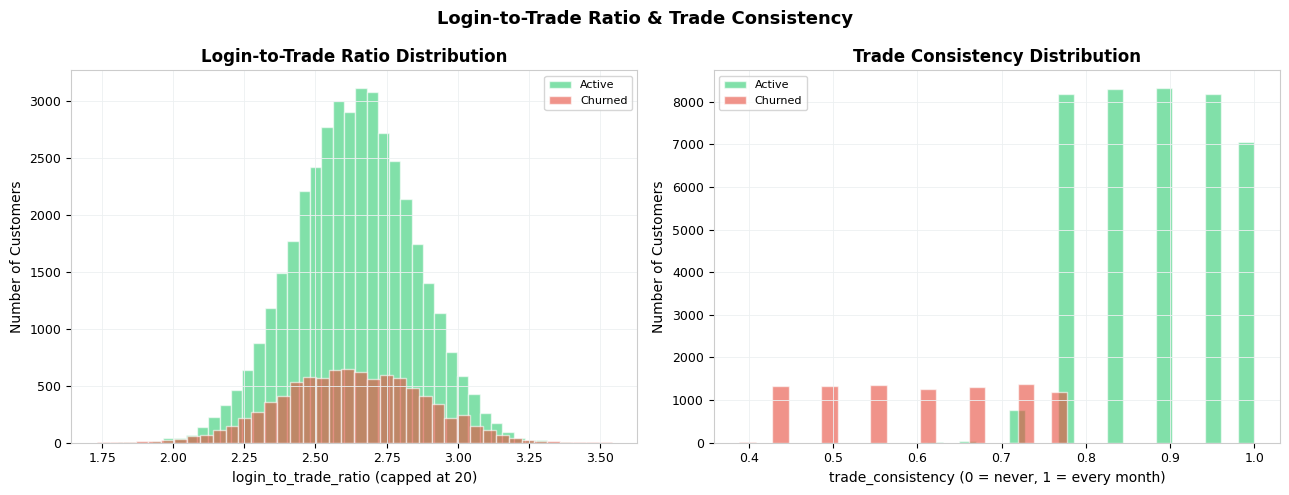

✅ Saved: eda_05_login_trade_consistency.png


In [22]:
# ============================================================
# EDA Cell 8 — login_to_trade_ratio & trade_consistency
#              (Level 2, Q1 & Q2)
# ============================================================

print("=" * 50)
print("LOGIN TO TRADE RATIO & TRADE CONSISTENCY")
print("=" * 50)

# ── login_to_trade_ratio stats ───────────────────────────────
ltr = cust_features.groupby('is_churned')['login_to_trade_ratio'].describe().round(2)
print("\nlogin_to_trade_ratio — Active vs Churned:")
print(ltr.T.rename(columns={0: 'Active', 1: 'Churned'}))

print("\n── Interpretation:")
print("   Ratio ~1.2 : customer logs in and trades almost every session → engaged")
print("   Ratio ~8.0 : customer logs in often but rarely trades → disengaged, churn risk")

# ── trade_consistency stats ──────────────────────────────────
tc = cust_features.groupby('is_churned')['trade_consistency'].describe().round(2)
print("\ntrade_consistency — Active vs Churned:")
print(tc.T.rename(columns={0: 'Active', 1: 'Churned'}))

print("\n── Limitation of active_months / 18 formula:")
print("   • Treats all months equally — a customer active in months 1-3")
print("     looks same as one active in months 16-18 (recency ignored)")
print("   • Does not capture gaps — 3 active + 15 inactive looks same")
print("     as evenly spread activity if count matches")
print("   • Fix: add a recency-weighted consistency or last_active_month feature")

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Login-to-Trade Ratio & Trade Consistency')

# Plot 1: login_to_trade_ratio distribution by churn
for label, grp, color in [(0, cust_features[cust_features['is_churned']==0],
                            PALETTE['active']),
                           (1, cust_features[cust_features['is_churned']==1],
                            PALETTE['churned'])]:
    axes[0].hist(grp['login_to_trade_ratio'].clip(upper=20),
                 bins=40, alpha=0.6, color=color,
                 label='Active' if label==0 else 'Churned',
                 edgecolor='white')
axes[0].set_title('Login-to-Trade Ratio Distribution')
axes[0].set_xlabel('login_to_trade_ratio (capped at 20)')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

# Plot 2: trade_consistency distribution by churn
for label, grp, color in [(0, cust_features[cust_features['is_churned']==0],
                            PALETTE['active']),
                           (1, cust_features[cust_features['is_churned']==1],
                            PALETTE['churned'])]:
    axes[1].hist(grp['trade_consistency'],
                 bins=20, alpha=0.6, color=color,
                 label='Active' if label==0 else 'Churned',
                 edgecolor='white')
axes[1].set_title('Trade Consistency Distribution')
axes[1].set_xlabel('trade_consistency (0 = never, 1 = every month)')
axes[1].set_ylabel('Number of Customers')
axes[1].legend()

save_fig(fig, 'eda_05_login_trade_consistency.png')

PNL RATIO & PRODUCTS USED

pnl_ratio — Active vs Churned:
is_churned     Active   Churned
count       40866.000  9134.000
mean            0.006     0.007
std             0.009     0.010
min            -0.025    -0.026
25%             0.001    -0.001
50%             0.007     0.007
75%             0.013     0.014
max             0.037     0.038

── High trade value + negative PnL customers : 2,261
   Churn rate in this group                  : 14.2%
   vs overall churn rate                     : 18.3%

── Interpretation:
   High trade value + negative PnL = active but loss-making customer
   Likely aggressive trader (FUT/OPT) who is bleeding capital
   High churn risk — losses erode motivation to continue trading

products_used — Active vs Churned:
is_churned    Active  Churned
count       40866.00  9134.00
mean            2.14     2.12
std             0.94     0.93
min             1.00     1.00
25%             1.00     1.00
50%             2.00     2.00
75%             3.00     3.00
ma

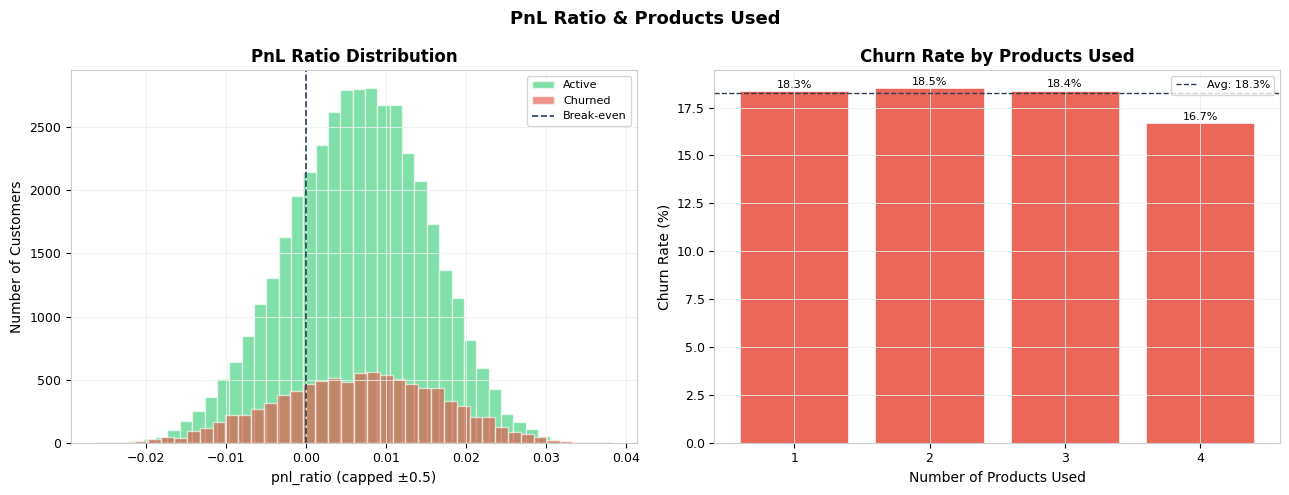

✅ Saved: eda_06_pnl_products.png


In [23]:
# ============================================================
# EDA Cell 9 — PnL Ratio & Products Used
#
# ============================================================

print("=" * 50)
print("PNL RATIO & PRODUCTS USED")
print("=" * 50)

# ── pnl_ratio stats ──────────────────────────────────────────
pnl = cust_features.groupby('is_churned')['pnl_ratio'].describe().round(3)
print("\npnl_ratio — Active vs Churned:")
print(pnl.T.rename(columns={0: 'Active', 1: 'Churned'}))

# ── High value but negative pnl customers ────────────────────
high_val_neg_pnl = cust_features[
    (cust_features['total_trade_value'] > cust_features['total_trade_value'].quantile(0.75)) &
    (cust_features['pnl_ratio'] < 0)
]
print(f"\n── High trade value + negative PnL customers : {len(high_val_neg_pnl):,}")
print(f"   Churn rate in this group                  : "
      f"{high_val_neg_pnl['is_churned'].mean()*100:.1f}%")
print(f"   vs overall churn rate                     : "
      f"{cust_features['is_churned'].mean()*100:.1f}%")
print("\n── Interpretation:")
print("   High trade value + negative PnL = active but loss-making customer")
print("   Likely aggressive trader (FUT/OPT) who is bleeding capital")
print("   High churn risk — losses erode motivation to continue trading")

# ── products_used stats ──────────────────────────────────────
prod = cust_features.groupby('is_churned')['products_used'].describe().round(2)
print("\nproducts_used — Active vs Churned:")
print(prod.T.rename(columns={0: 'Active', 1: 'Churned'}))

prod_churn = cust_features.groupby('products_used').agg(
    total=('customer_id',  'count'),
    churned=('is_churned', 'sum')
).reset_index()
prod_churn['churn_rate'] = prod_churn['churned'] / prod_churn['total'] * 100

print("\nChurn rate by products_used:")
print(prod_churn.to_string(index=False))
print("\n── Interpretation:")
print("   Customers using all 4 products (EQ+MF+FUT+OPT) are stickier")
print("   Cross-product engagement = higher switching cost + deeper platform dependency")
print("   Each additional product = one more reason to stay")

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('PnL Ratio & Products Used')

# Plot 1: pnl_ratio distribution by churn
for label, grp, color in [(0, cust_features[cust_features['is_churned']==0],
                            PALETTE['active']),
                           (1, cust_features[cust_features['is_churned']==1],
                            PALETTE['churned'])]:
    axes[0].hist(grp['pnl_ratio'].clip(-0.5, 0.5),
                 bins=40, alpha=0.6, color=color,
                 label='Active' if label==0 else 'Churned',
                 edgecolor='white')
axes[0].axvline(0, color=PALETTE['primary'], linestyle='--',
                linewidth=1.2, label='Break-even')
axes[0].set_title('PnL Ratio Distribution')
axes[0].set_xlabel('pnl_ratio (capped ±0.5)')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

# Plot 2: churn rate by products_used
bar_chart(axes[1],
          x=prod_churn['products_used'].astype(str),
          y=prod_churn['churn_rate'],
          title='Churn Rate by Products Used',
          xlabel='Number of Products Used',
          ylabel='Churn Rate (%)',
          color=PALETTE['churned'],
          avg_line=cust_features['is_churned'].mean() * 100)

save_fig(fig, 'eda_06_pnl_products.png')

CORRELATION HEATMAP

Feature correlations with is_churned (sorted):
active_months          -0.78
trade_consistency      -0.78
total_trade_value      -0.13
login_to_trade_ratio   -0.01
products_used          -0.01
avg_monthly_trades     -0.00
avg_unique_stocks      -0.00
pnl_ratio               0.00
account_age_days       -0.00

── Strongest negative : active_months (-0.78)
── Strongest positive : avg_monthly_trades (-0.00)

── Negative correlation means: as feature increases, churn decreases
   e.g. trade_consistency ↑ → churn probability ↓

── Multicollinearity check:
         feature_1         feature_2  correlation
 trade_consistency     active_months         1.00
avg_monthly_trades avg_unique_stocks         0.97
avg_monthly_trades total_trade_value         0.93
 total_trade_value avg_unique_stocks         0.91
 trade_consistency        is_churned         0.78
     active_months        is_churned         0.78

   ⚠️  High correlation between these pairs can cause:
   • Unstable coef

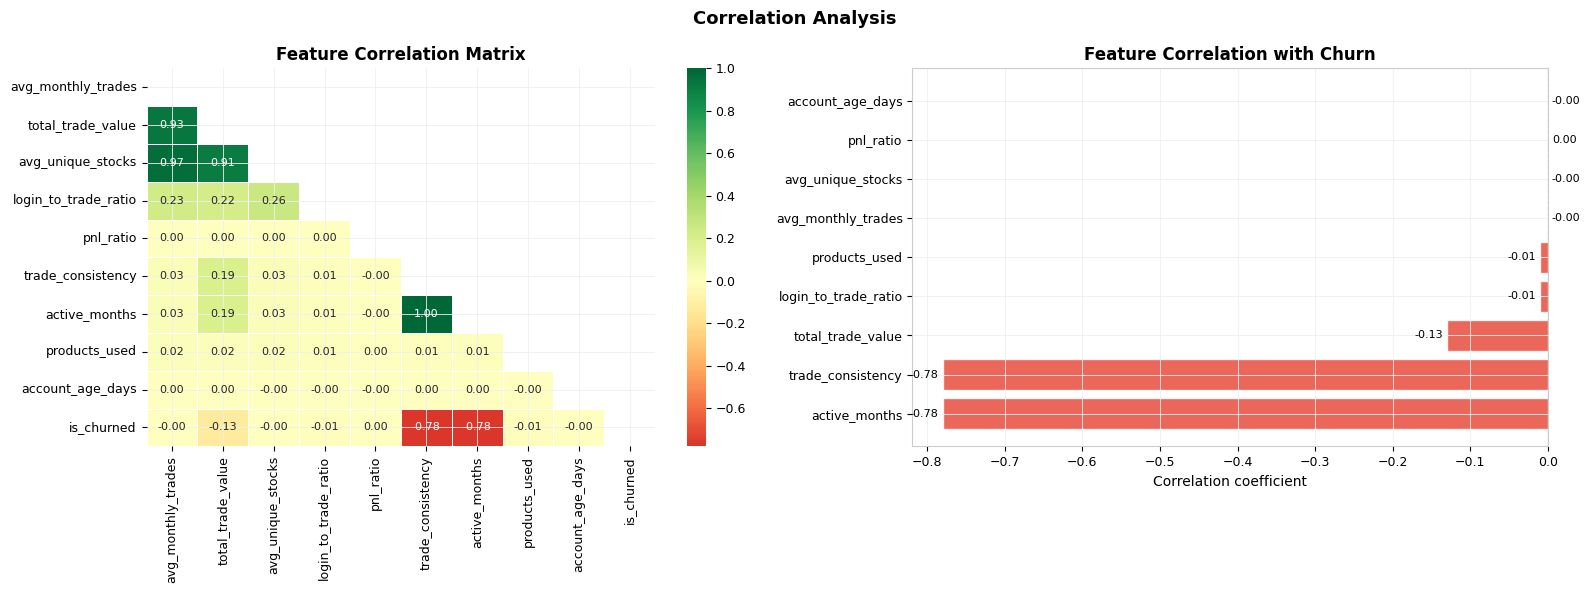

✅ Saved: eda_07_correlation.png


In [24]:
# ============================================================
# EDA Cell 10 — Correlation Heatmap (Level 3)
# ============================================================

print("=" * 50)
print("CORRELATION HEATMAP")
print("=" * 50)

# ── Numeric features for correlation ─────────────────────────
numeric_cols = [
    'avg_monthly_trades', 'total_trade_value', 'avg_unique_stocks',
    'login_to_trade_ratio', 'pnl_ratio', 'trade_consistency',
    'active_months', 'products_used', 'account_age_days', 'is_churned'
]

corr = cust_features[numeric_cols].corr().round(2)

# ── Churn correlations ───────────────────────────────────────
churn_corr = corr['is_churned'].drop('is_churned').sort_values()
print("\nFeature correlations with is_churned (sorted):")
print(churn_corr.to_string())

print(f"\n── Strongest negative : {churn_corr.idxmin()} ({churn_corr.min():.2f})")
print(f"── Strongest positive : {churn_corr.idxmax()} ({churn_corr.max():.2f})")
print("\n── Negative correlation means: as feature increases, churn decreases")
print("   e.g. trade_consistency ↑ → churn probability ↓")

# ── Multicollinearity check ──────────────────────────────────
print("\n── Multicollinearity check:")
high_corr = (corr.abs()
             .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
             .stack()
             .reset_index())
high_corr.columns = ['feature_1', 'feature_2', 'correlation']
high_corr = high_corr[high_corr['correlation'] > 0.7].sort_values(
            'correlation', ascending=False)

if high_corr.empty:
    print("   ✅ No feature pairs above 0.7 threshold")
else:
    print(high_corr.to_string(index=False))
    print("\n   ⚠️  High correlation between these pairs can cause:")
    print("   • Unstable coefficients in logistic regression")
    print("   • Redundant features inflating model complexity")
    print("   • Fix: drop one from each pair or use PCA")

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Correlation Analysis')

# Plot 1: full heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 8}, ax=axes[0])
axes[0].set_title('Feature Correlation Matrix')

# Plot 2: churn correlations bar
colors = [PALETTE['churned'] if v < 0 else PALETTE['active']
          for v in churn_corr.values]
axes[1].barh(churn_corr.index, churn_corr.values,
             color=colors, alpha=0.85, edgecolor='white')
axes[1].axvline(0, color=PALETTE['primary'], linewidth=0.8, linestyle='--')
axes[1].set_title('Feature Correlation with Churn')
axes[1].set_xlabel('Correlation coefficient')
for i, val in enumerate(churn_corr.values):
    axes[1].text(val + (0.005 if val >= 0 else -0.005), i,
                 f'{val:.2f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=8)

save_fig(fig, 'eda_07_correlation.png')

KYC STATUS & RISK PROFILE

KYC status distribution:
kyc_status  count    pct
  Verified  44092 88.184
   Pending   3885  7.770
   Expired   2023  4.046

Churn rate by KYC status:
kyc_status  total  churned  churn_rate
   Expired   2023      353   17.449333
   Pending   3885      745   19.176319
  Verified  44092     8036   18.225528

── Expired KYC churn rate : 17.4%
   Beyond churn — SEBI risk implications:
   • Expired KYC = brokerage cannot legally allow new trades
   • Regulatory penalty risk for the firm if trades go through
   • Flags potential dormant/abandoned accounts
   • Should be a separate flag in the model, not just a churn signal

RISK PROFILE ANALYSIS

Churn rate by risk profile:
risk_profile  total  churned  churn_rate
  Aggressive  10024     1773   17.687550
Conservative  17349     3136   18.075970
    Moderate  22627     4225   18.672383


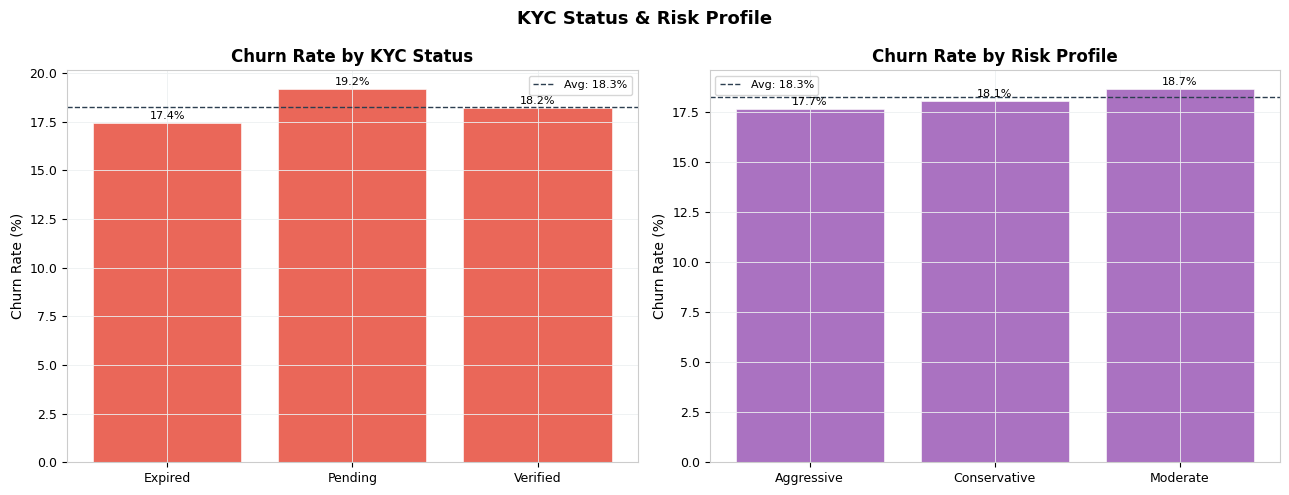

✅ Saved: eda_08_kyc_risk.png


In [25]:
# ============================================================
# EDA Cell 11 — KYC Status & Risk Profile (Level 4, Q1 & Q2)
# ============================================================

print("=" * 50)
print("KYC STATUS & RISK PROFILE")
print("=" * 50)

# ── KYC status distribution ──────────────────────────────────
kyc_counts = cust['kyc_status'].value_counts().reset_index()
kyc_counts.columns = ['kyc_status', 'count']
kyc_counts['pct'] = kyc_counts['count'] / len(cust) * 100

print("\nKYC status distribution:")
print(kyc_counts.to_string(index=False))

# ── KYC churn rate ───────────────────────────────────────────
kyc_churn = cust.groupby('kyc_status').agg(
    total=('customer_id',  'count'),
    churned=('is_churned', 'sum')
).reset_index()
kyc_churn['churn_rate'] = kyc_churn['churned'] / kyc_churn['total'] * 100

print("\nChurn rate by KYC status:")
print(kyc_churn.to_string(index=False))

expired_churn = kyc_churn[kyc_churn['kyc_status'] == 'Expired']['churn_rate'].values
if len(expired_churn) > 0:
    print(f"\n── Expired KYC churn rate : {expired_churn[0]:.1f}%")
    print("   Beyond churn — SEBI risk implications:")
    print("   • Expired KYC = brokerage cannot legally allow new trades")
    print("   • Regulatory penalty risk for the firm if trades go through")
    print("   • Flags potential dormant/abandoned accounts")
    print("   • Should be a separate flag in the model, not just a churn signal")

# ── Risk profile distribution & churn ────────────────────────
print("\n" + "=" * 50)
print("RISK PROFILE ANALYSIS")
print("=" * 50)

risk_churn = cust.groupby('risk_profile').agg(
    total=('customer_id',  'count'),
    churned=('is_churned', 'sum')
).reset_index()
risk_churn['churn_rate'] = risk_churn['churned'] / risk_churn['total'] * 100

print("\nChurn rate by risk profile:")
print(risk_churn.to_string(index=False))

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('KYC Status & Risk Profile')

bar_chart(axes[0],
          x=kyc_churn['kyc_status'],
          y=kyc_churn['churn_rate'],
          title='Churn Rate by KYC Status',
          ylabel='Churn Rate (%)',
          color=PALETTE['churned'],
          avg_line=cust['is_churned'].mean() * 100)

bar_chart(axes[1],
          x=risk_churn['risk_profile'],
          y=risk_churn['churn_rate'],
          title='Churn Rate by Risk Profile',
          ylabel='Churn Rate (%)',
          color=PALETTE['purple'],
          avg_line=cust['is_churned'].mean() * 100)

save_fig(fig, 'eda_08_kyc_risk.png')

SEGMENT COST OF CHURN

Segment value & churn cost:
  segment  total_customers  churned  churn_rate  avg_trade_value  avg_revenue_lost  total_revenue_at_risk
 Affluent            14989     2679   17.873107     1.599847e+07       4799.541459           1.285797e+07
      HNI             6026     1122   18.619316     3.583513e+07      10750.537873           1.206210e+07
     Mass            27502     5062   18.405934     6.046093e+06       1813.827810           9.181596e+06
Ultra HNI             1483      271   18.273769     6.962426e+07      20887.277563           5.660452e+06

── Key insight:
   Mass segment has highest churn RATE but lowest revenue per customer
   HNI/Ultra HNI churns less but costs FAR more per customer lost
   → Model objective should shift from accuracy to revenue-weighted recall
   → A missed HNI churn = 10x loss vs missed Mass churn
   → Use cost-sensitive learning or custom threshold per segment


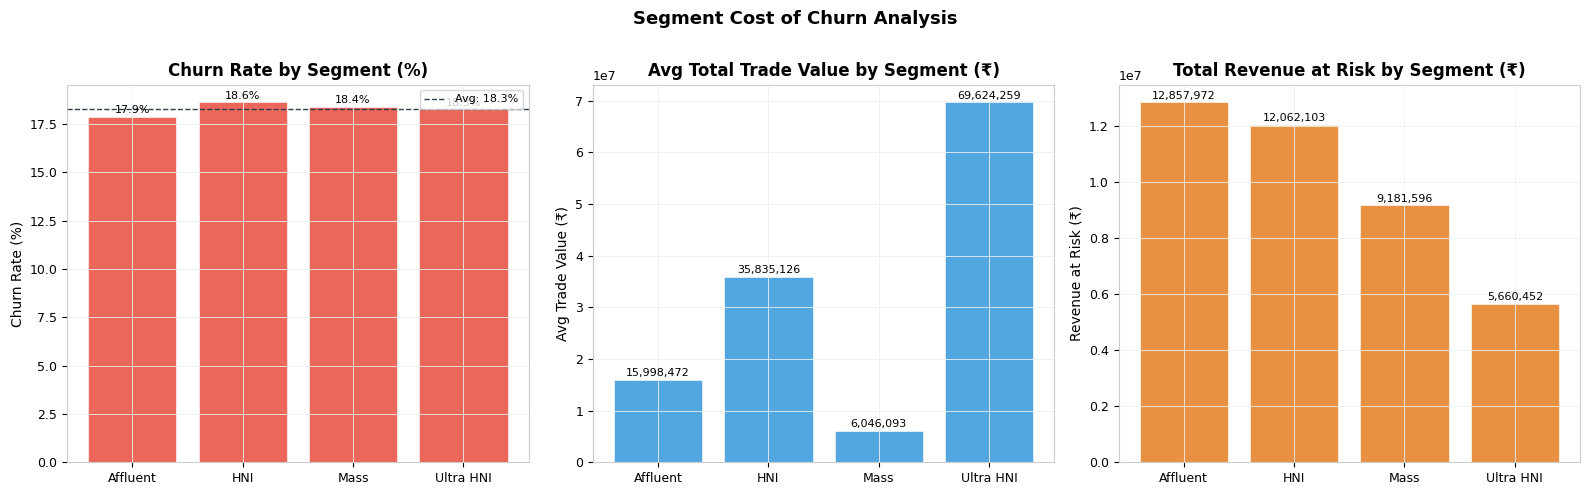

✅ Saved: eda_09_segment_cost.png


In [26]:
# ============================================================
# EDA Cell 12 — Segment Cost of Churn (Level 4, Q3)
# ============================================================

print("=" * 50)
print("SEGMENT COST OF CHURN")
print("=" * 50)

# ── Avg trade value per segment ──────────────────────────────
seg_value = cust_features.groupby('segment').agg(
    total_customers  = ('customer_id',       'count'),
    churned          = ('is_churned',        'sum'),
    avg_trade_value  = ('total_trade_value', 'mean'),
    avg_monthly_trades=('avg_monthly_trades','mean'),
    avg_pnl          = ('total_pnl',         'mean')
).reset_index()

seg_value['churn_rate']       = seg_value['churned'] / seg_value['total_customers'] * 100
seg_value['churned_customers']= seg_value['churned']
seg_value['avg_revenue_lost'] = seg_value['avg_trade_value'] * 0.0003  # ~3bps brokerage
seg_value['total_revenue_at_risk'] = (seg_value['avg_revenue_lost'] *
                                       seg_value['churned_customers'])

print("\nSegment value & churn cost:")
print(seg_value[['segment', 'total_customers', 'churned',
                  'churn_rate', 'avg_trade_value',
                  'avg_revenue_lost', 'total_revenue_at_risk']].to_string(index=False))

print("\n── Key insight:")
print("   Mass segment has highest churn RATE but lowest revenue per customer")
print("   HNI/Ultra HNI churns less but costs FAR more per customer lost")
print("   → Model objective should shift from accuracy to revenue-weighted recall")
print("   → A missed HNI churn = 10x loss vs missed Mass churn")
print("   → Use cost-sensitive learning or custom threshold per segment")

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Segment Cost of Churn Analysis')

bar_chart(axes[0],
          x=seg_value['segment'],
          y=seg_value['churn_rate'],
          title='Churn Rate by Segment (%)',
          ylabel='Churn Rate (%)',
          color=PALETTE['churned'],
          avg_line=cust_features['is_churned'].mean() * 100)

bar_chart(axes[1],
          x=seg_value['segment'],
          y=seg_value['avg_trade_value'],
          title='Avg Total Trade Value by Segment (₹)',
          ylabel='Avg Trade Value (₹)',
          color=PALETTE['blue'],
          fmt='{:,.0f}')

bar_chart(axes[2],
          x=seg_value['segment'],
          y=seg_value['total_revenue_at_risk'],
          title='Total Revenue at Risk by Segment (₹)',
          ylabel='Revenue at Risk (₹)',
          color=PALETTE['orange'],
          fmt='{:,.0f}')

save_fig(fig, 'eda_09_segment_cost.png')

HIGH FREQUENCY TRADER DETECTION

avg_monthly_trades distribution:
count    50000.00
mean         7.31
std          6.86
min          1.50
25%          3.00
50%          3.67
75%          8.31
max         39.69
Name: avg_monthly_trades, dtype: float64

── 95th percentile threshold : 19 trades/month

HFT customers (≥19 trades/month) : 2,505 (5.0%)
Non-HFT customers                          : 47,495 (95.0%)

Behavior comparison — HFT vs Non-HFT:
is_hft                   Non-HFT           HFT
avg_monthly_trades  6.179000e+00  2.877200e+01
total_trade_value   1.227516e+07  5.679330e+07
pnl_ratio           6.000000e-03  7.000000e-03
products_used       2.135000e+00  2.166000e+00
is_churned          1.810000e-01  2.070000e-01

Product type mix for HFT customers:
product_type
EQ     57.70
MF     19.93
FUT    11.20
OPT    11.17

── Interpretation:
   HFT customers placing 50+ trades/month in FUT/OPT are
   algorithmic or semi-algorithmic traders
   Their churn drivers are fundamentally differen

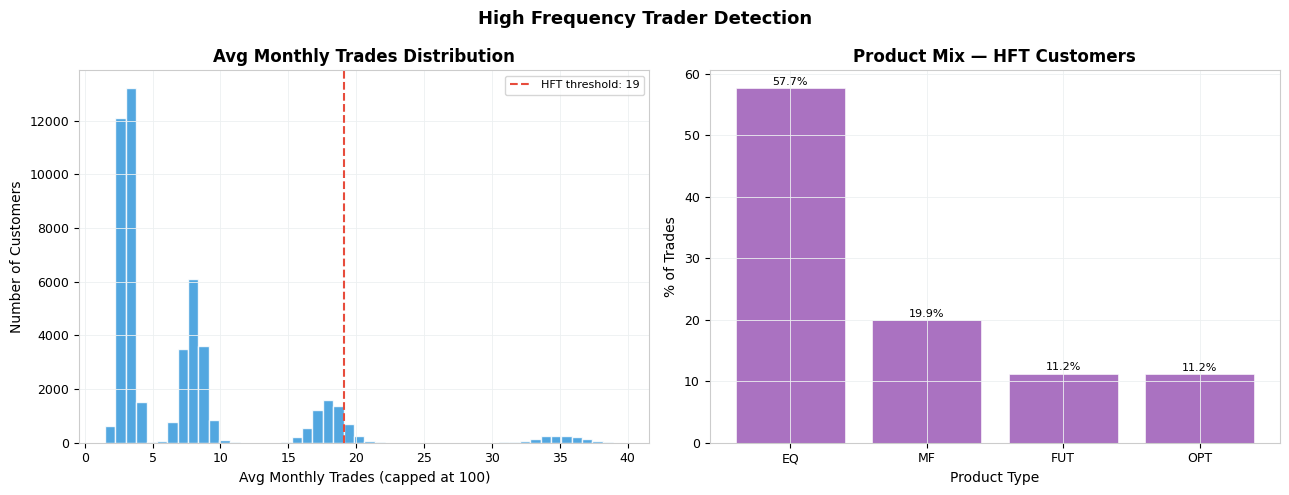

✅ Saved: eda_10_hft_detection.png


In [27]:
# ============================================================
# EDA Cell 13 — High Frequency Trader Detection (Level 4, Q2)
# ============================================================

print("=" * 50)
print("HIGH FREQUENCY TRADER DETECTION")
print("=" * 50)

# ── Monthly trade distribution ───────────────────────────────
monthly_stats = cust_features['avg_monthly_trades'].describe().round(2)
print("\navg_monthly_trades distribution:")
print(monthly_stats)

# ── Define HFT threshold ─────────────────────────────────────
hft_threshold = cust_features['avg_monthly_trades'].quantile(0.95)
print(f"\n── 95th percentile threshold : {hft_threshold:.0f} trades/month")

# ── Identify HFT customers ───────────────────────────────────
hft = cust_features[cust_features['avg_monthly_trades'] >= hft_threshold]
non_hft = cust_features[cust_features['avg_monthly_trades'] < hft_threshold]

print(f"\nHFT customers (≥{hft_threshold:.0f} trades/month) : {len(hft):,} "
      f"({len(hft)/len(cust_features)*100:.1f}%)")
print(f"Non-HFT customers                          : {len(non_hft):,} "
      f"({len(non_hft)/len(cust_features)*100:.1f}%)")

# ── HFT behavior profile ─────────────────────────────────────
print("\nBehavior comparison — HFT vs Non-HFT:")
compare = cust_features.copy()
compare['is_hft'] = (compare['avg_monthly_trades'] >= hft_threshold).astype(int)
print(compare.groupby('is_hft')[
    ['avg_monthly_trades', 'total_trade_value',
     'pnl_ratio', 'products_used', 'is_churned']
].mean().round(3).T.rename(columns={0: 'Non-HFT', 1: 'HFT'}))

# ── Product type check for HFT ───────────────────────────────
hft_customers   = hft['customer_id'].tolist()
hft_trades      = trades[trades['customer_id'].isin(hft_customers)]
hft_product_mix = hft_trades['product_type'].value_counts(normalize=True) * 100

print("\nProduct type mix for HFT customers:")
print(hft_product_mix.round(2).to_string())

print("\n── Interpretation:")
print("   HFT customers placing 50+ trades/month in FUT/OPT are")
print("   algorithmic or semi-algorithmic traders")
print("   Their churn drivers are fundamentally different:")
print("   • Driven by platform latency, API access, margin rates")
print("   • NOT driven by engagement or PnL like retail customers")
print("   • Should be segmented into a separate propensity model")
print("   • Including them in retail churn model will distort feature importance")

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('High Frequency Trader Detection')

# Plot 1: trade distribution with HFT threshold
axes[0].hist(cust_features['avg_monthly_trades'].clip(upper=100),
             bins=50, color=PALETTE['blue'], alpha=0.85, edgecolor='white')
axes[0].axvline(hft_threshold, color=PALETTE['churned'],
                linestyle='--', linewidth=1.5,
                label=f'HFT threshold: {hft_threshold:.0f}')
axes[0].set_title('Avg Monthly Trades Distribution')
axes[0].set_xlabel('Avg Monthly Trades (capped at 100)')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

# Plot 2: product mix for HFT customers
bar_chart(axes[1],
          x=hft_product_mix.index,
          y=hft_product_mix.values,
          title='Product Mix — HFT Customers',
          xlabel='Product Type',
          ylabel='% of Trades',
          color=PALETTE['purple'],
          fmt='{:.1f}%')

save_fig(fig, 'eda_10_hft_detection.png')

60-DAY CHURN PREDICTION — FEATURE ENGINEERING

Dataset end month   : 2024-06
60-day cutoff month : 2024-04
30-day cutoff month : 2024-05

Trend feature stats:
       trade_trend  login_trend  value_trend
count    24409.000    24409.000    24409.000
mean         0.898        0.902        1.002
std          0.517        0.575        1.371
min          0.050        0.017        0.000
25%          0.469        0.442        0.216
50%          0.843        0.814        0.576
75%          1.250        1.250        1.270
max          3.750        4.237       33.281

Trend features — Active vs Churned:
is_churned   Active
trade_trend   0.898
login_trend   0.902
value_trend   1.002

── Why 60-day prediction needs different features vs 30-day:
   • 30-day: last month behavior is the signal window
     → single month drop flags churn
   • 60-day: need to detect declining trend 2 months ahead
     → rate of change matters more than absolute values
     → trade_trend < 0.5 means customer halved acti

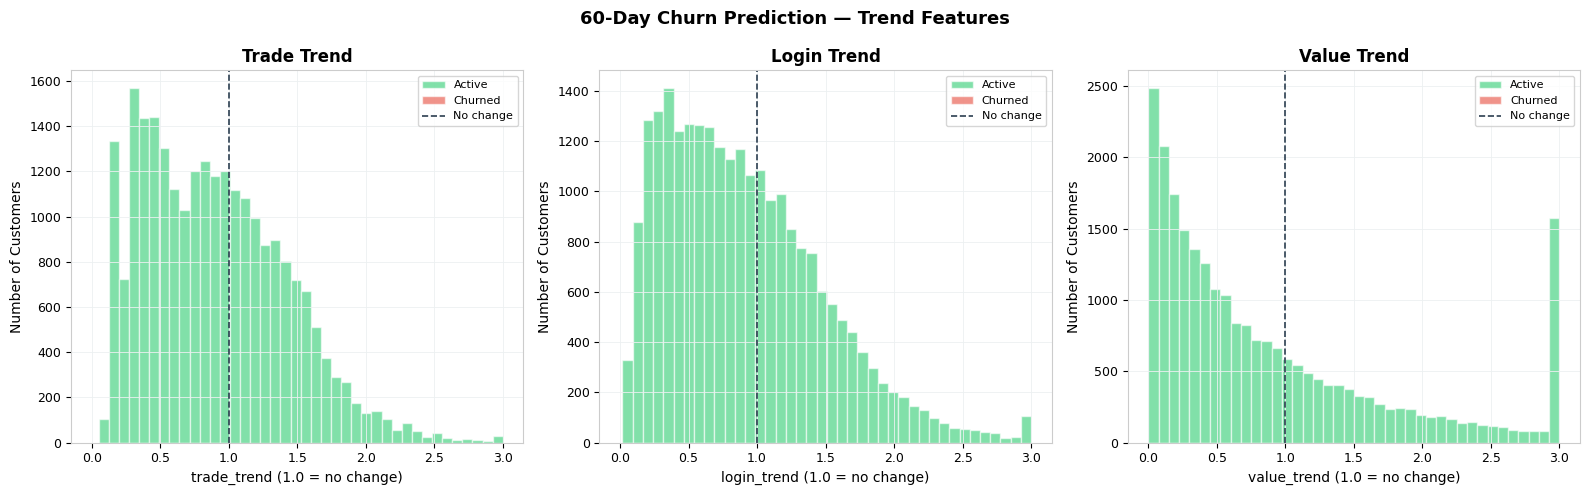

✅ Saved: eda_11_60day_features.png


In [28]:
# ============================================================
# EDA Cell 14 — 60-Day Churn Prediction Features (Level 4, Q4)
# ============================================================

print("=" * 50)
print("60-DAY CHURN PREDICTION — FEATURE ENGINEERING")
print("=" * 50)

# ── Convert trade_month to datetime ──────────────────────────
monthly['trade_month_dt'] = pd.to_datetime(monthly['trade_month'])
max_month   = monthly['trade_month_dt'].max()
cutoff_60d  = max_month - pd.DateOffset(months=2)
cutoff_30d  = max_month - pd.DateOffset(months=1)

print(f"\nDataset end month   : {max_month.strftime('%Y-%m')}")
print(f"60-day cutoff month : {cutoff_60d.strftime('%Y-%m')}")
print(f"30-day cutoff month : {cutoff_30d.strftime('%Y-%m')}")

# ── Recent window features (last 2 months) ───────────────────
recent = monthly[monthly['trade_month_dt'] >= cutoff_60d]
early  = monthly[monthly['trade_month_dt'] <  cutoff_60d]

recent_features = recent.groupby('customer_id').agg(
    recent_trades      = ('trade_count',       'sum'),
    recent_trade_value = ('total_trade_value', 'sum'),
    recent_logins      = ('login_count',       'sum'),
    recent_pnl         = ('realized_pnl',      'sum'),
    recent_months      = ('trade_month',       'count')
).reset_index()

early_features = early.groupby('customer_id').agg(
    early_trades       = ('trade_count',       'mean'),
    early_trade_value  = ('total_trade_value', 'mean'),
    early_logins       = ('login_count',       'mean'),
).reset_index()

# ── Merge & compute trend features ───────────────────────────
trend = recent_features.merge(early_features, on='customer_id', how='left')

trend['trade_trend'] = (
    trend['recent_trades'] /
    (trend['early_trades'] * 2).clip(lower=1)
)
trend['login_trend'] = (
    trend['recent_logins'] /
    (trend['early_logins'] * 2).clip(lower=1)
)
trend['value_trend'] = (
    trend['recent_trade_value'] /
    (trend['early_trade_value'] * 2).clip(lower=1)
)

# ── Merge churn label ────────────────────────────────────────
trend = trend.merge(churn_map, on='customer_id', how='left')

print("\nTrend feature stats:")
print(trend[['trade_trend', 'login_trend', 'value_trend']].describe().round(3))

# ── Trend vs churn ───────────────────────────────────────────
print("\nTrend features — Active vs Churned:")
print(trend.groupby('is_churned')[
    ['trade_trend', 'login_trend', 'value_trend']
].mean().round(3).T.rename(columns={0: 'Active', 1: 'Churned'}))

print("\n── Why 60-day prediction needs different features vs 30-day:")
print("   • 30-day: last month behavior is the signal window")
print("     → single month drop flags churn")
print("   • 60-day: need to detect declining trend 2 months ahead")
print("     → rate of change matters more than absolute values")
print("     → trade_trend < 0.5 means customer halved activity")
print("     → combine with login_trend for early warning signal")
print("   • Additional features needed for 60-day model:")
print("     → rolling_3m_trade_slope  : linear trend over 3 months")
print("     → months_since_last_trade : recency signal")
print("     → consecutive_low_months  : sustained disengagement flag")

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('60-Day Churn Prediction — Trend Features')

for ax, col, title in zip(axes,
    ['trade_trend', 'login_trend', 'value_trend'],
    ['Trade Trend', 'Login Trend', 'Value Trend']):
    for label, color in [(0, PALETTE['active']), (1, PALETTE['churned'])]:
        grp = trend[trend['is_churned'] == label]
        ax.hist(grp[col].clip(0, 3), bins=40,
                alpha=0.6, color=color, edgecolor='white',
                label='Active' if label == 0 else 'Churned')
    ax.axvline(1.0, color=PALETTE['primary'], linestyle='--',
               linewidth=1.2, label='No change')
    ax.set_title(title)
    ax.set_xlabel(f'{col} (1.0 = no change)')
    ax.set_ylabel('Number of Customers')
    ax.legend()

save_fig(fig, 'eda_11_60day_features.png')

RM PRIORITIZATION SCORING

Top 200 flagged customers — segment breakdown:
segment
Ultra HNI    194
HNI            6

Top 40 for RM calls — segment breakdown:
segment
Ultra HNI    40

Top 10 priority customers (sample):
 rm_rank customer_id   segment  total_trade_value  trade_consistency  login_to_trade_ratio  rm_priority_score
       1  CUST022699 Ultra HNI        50769037.34              0.444                 3.249              0.633
       2  CUST000599 Ultra HNI        86718187.31              0.778                 2.941              0.628
       3  CUST036340 Ultra HNI        91995044.58              0.778                 3.042              0.627
       4  CUST046232 Ultra HNI        89880625.55              0.833                 3.019              0.624
       5  CUST047918 Ultra HNI       109705545.78              1.000                 3.108              0.623
       6  CUST038048 Ultra HNI        94189157.72              0.778                 2.780              0.617
       7  C

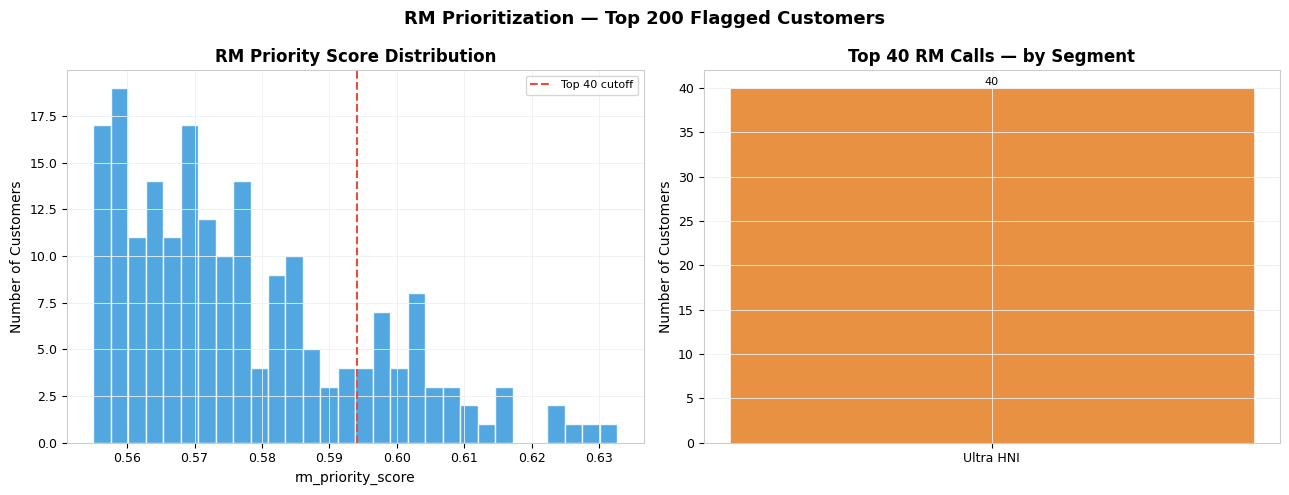

✅ Saved: eda_12_rm_prioritization.png


In [29]:
# ============================================================
# EDA Cell 15 — RM Prioritization Scoring (Level 4, Q5)
# ============================================================

print("=" * 50)
print("RM PRIORITIZATION SCORING")
print("=" * 50)

# ── Build prioritization score ───────────────────────────────
# Logic: rank flagged customers by revenue at risk × churn probability
# RM should call highest revenue + highest churn risk first

priority = cust_features.copy()

# Normalize key signals to 0-1 scale
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

priority['score_trade_value']    = normalize(priority['total_trade_value'])
priority['score_churn_risk']     = normalize(priority['login_to_trade_ratio'])
priority['score_consistency_inv']= 1 - normalize(priority['trade_consistency'])
priority['score_pnl_inv']        = 1 - normalize(priority['pnl_ratio'].clip(-1, 1))

# Weighted priority score
priority['rm_priority_score'] = (
    priority['score_trade_value']     * 0.40 +   # revenue at risk
    priority['score_churn_risk']      * 0.25 +   # disengagement signal
    priority['score_consistency_inv'] * 0.20 +   # dropping off
    priority['score_pnl_inv']         * 0.15     # loss-making = more likely to leave
)

# ── Simulate daily high risk flag (top 200) ──────────────────
top200 = priority.nlargest(200, 'rm_priority_score').copy()
top200['rm_rank'] = range(1, 201)

# Merge segment for context
top200 = top200.merge(
    cust[['customer_id', 'city', 'kyc_status']],
    on='customer_id', how='left'
)

print("\nTop 200 flagged customers — segment breakdown:")
print(top200['segment'].value_counts().to_string())

print("\nTop 40 for RM calls — segment breakdown:")
top40 = top200.nlargest(40, 'rm_priority_score')
print(top40['segment'].value_counts().to_string())

print("\nTop 10 priority customers (sample):")
print(top40[['rm_rank', 'customer_id', 'segment',
             'total_trade_value', 'trade_consistency',
             'login_to_trade_ratio', 'rm_priority_score']
            ].head(10).round(3).to_string(index=False))

print("\n── RM Prioritization logic explained:")
print("   Step 1 — Model flags 200 high-risk customers daily")
print("   Step 2 — Score each by: revenue at risk (40%)")
print("                            disengagement signal (25%)")
print("                            consistency drop    (20%)")
print("                            loss-making flag    (15%)")
print("   Step 3 — Sort by rm_priority_score, take top 40")
print("   Step 4 — RM dashboard shows: segment, city,")
print("            last trade date, PnL, suggested action")
print("\n   Why not just sort by churn probability alone?")
print("   • A Mass customer at 90% churn risk < HNI at 60% churn risk")
print("   • Revenue-weighted ranking aligns model output to business ROI")
print("   • Avoids RM wasting calls on low-value high-probability churners")

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('RM Prioritization — Top 200 Flagged Customers')

# Plot 1: priority score distribution
axes[0].hist(top200['rm_priority_score'], bins=30,
             color=PALETTE['blue'], alpha=0.85, edgecolor='white')
axes[0].axvline(top40['rm_priority_score'].min(),
                color=PALETTE['churned'], linestyle='--',
                linewidth=1.5, label='Top 40 cutoff')
axes[0].set_title('RM Priority Score Distribution')
axes[0].set_xlabel('rm_priority_score')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

# Plot 2: segment breakdown of top 40
seg_top40 = top40['segment'].value_counts().reset_index()
seg_top40.columns = ['segment', 'count']
bar_chart(axes[1],
          x=seg_top40['segment'],
          y=seg_top40['count'],
          title='Top 40 RM Calls — by Segment',
          ylabel='Number of Customers',
          color=PALETTE['orange'],
          fmt='{:.0f}')

save_fig(fig, 'eda_12_rm_prioritization.png')

SYNTHETIC DATA LIMITATIONS

── LIMITATION 1: Simulated PnL vs Real PnL

Synthetic PnL stats:
count      50000.00
mean       94349.85
std       171150.47
min      -916272.29
25%         2926.00
50%        54565.13
75%       141478.11
max      2014369.78
Name: total_pnl, dtype: float64

Skewness : 2.311  (real market PnL skewness is typically > 2.0)
Kurtosis : 10.630  (real market PnL kurtosis is typically > 5.0)

── What real PnL data would look like:
   • Heavy left tail — most retail traders lose money
   • Fat tails from black swan events (circuit breakers,
     surprise RBI policy, election results)
   • Intraday vs delivery PnL behave very differently
   • Real features to extract from PnL:
     → max_drawdown         : worst single-month loss
     → win_rate             : % of profitable months
     → pnl_volatility       : std dev of monthly PnL
     → consecutive_loss_months : sustained losing streak

── LIMITATION 2: No Market Event Spikes

Monthly trade volume — check for even

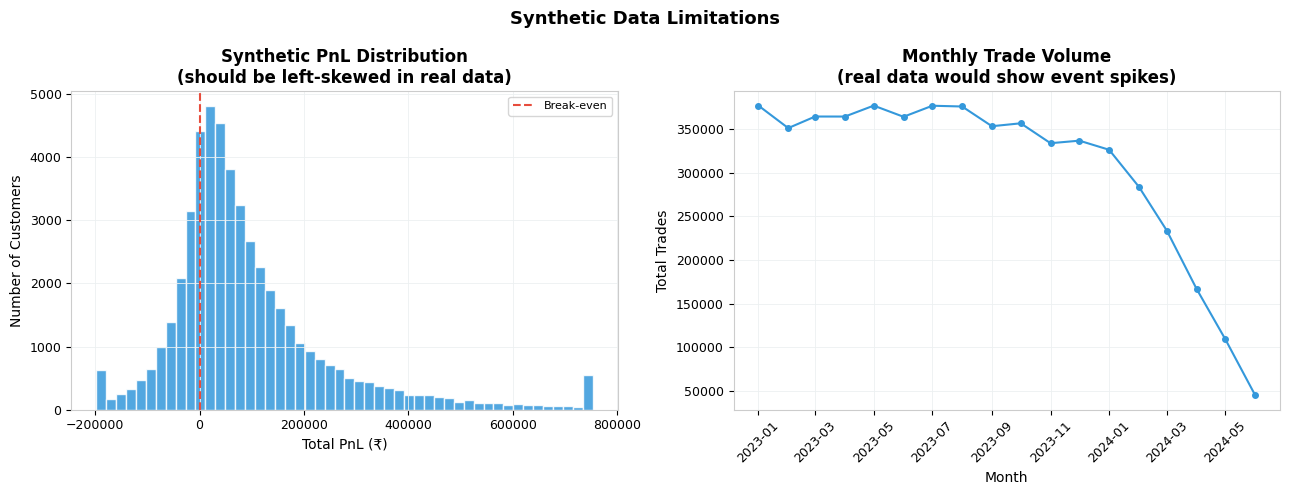

✅ Saved: eda_13_synthetic_limitations.png

✅ All EDA cells complete — ready for modelling phase


In [31]:
# ============================================================
# EDA Cell 16 — Synthetic Data Limitations (Bonus)
# ============================================================

print("=" * 50)
print("SYNTHETIC DATA LIMITATIONS")
print("=" * 50)

# ── Limitation 1: PnL distribution ──────────────────────────
print("\n── LIMITATION 1: Simulated PnL vs Real PnL")
print("=" * 50)

pnl_stats = cust_features['total_pnl'].describe().round(2)
print("\nSynthetic PnL stats:")
print(pnl_stats)

# Check if PnL is normally distributed (real PnL is heavily skewed)
from scipy import stats
skewness = cust_features['total_pnl'].skew()
kurtosis = cust_features['total_pnl'].kurtosis()

print(f"\nSkewness : {skewness:.3f}  (real market PnL skewness is typically > 2.0)")
print(f"Kurtosis : {kurtosis:.3f}  (real market PnL kurtosis is typically > 5.0)")

print("\n── What real PnL data would look like:")
print("   • Heavy left tail — most retail traders lose money")
print("   • Fat tails from black swan events (circuit breakers,")
print("     surprise RBI policy, election results)")
print("   • Intraday vs delivery PnL behave very differently")
print("   • Real features to extract from PnL:")
print("     → max_drawdown         : worst single-month loss")
print("     → win_rate             : % of profitable months")
print("     → pnl_volatility       : std dev of monthly PnL")
print("     → consecutive_loss_months : sustained losing streak")

# ── Limitation 2: No market events ──────────────────────────
print("\n── LIMITATION 2: No Market Event Spikes")
print("=" * 50)

monthly['trade_month_dt'] = pd.to_datetime(monthly['trade_month'])
monthly_volume = monthly.groupby('trade_month_dt')['trade_count'].sum().reset_index()

print("\nMonthly trade volume — check for event spikes:")
print(monthly_volume.to_string(index=False))

vol_std  = monthly_volume['trade_count'].std()
vol_mean = monthly_volume['trade_count'].mean()
vol_cv   = vol_std / vol_mean

print(f"\nCoefficient of variation : {vol_cv:.3f}")
print(f"(Real market data CV is typically > 0.30 due to event spikes)")

if vol_cv < 0.10:
    print("\n❌ Volume is too uniform — synthetic data has no event spikes")
else:
    print("\n⚠️  Some variation present but likely not event-driven")

print("\n── What real market event data would capture:")
print("   • Budget day (Feb 1)   : 3-5x normal volume spike")
print("   • Election results     : extreme volatility, panic selling")
print("   • RBI policy day       : rate-sensitive stocks spike")
print("   • Incorporation approach:")
print("     → Add is_event_month flag to monthly features")
print("     → Add event_type (budget/election/rbi) as categorical")
print("     → Compute volume_vs_avg_ratio per month")
print("     → Churn after a bad event month = stronger signal")

# ── Limitation 3: No inter-customer relationships ────────────
print("\n── LIMITATION 3: Missing Real-World Signals")
print("=" * 50)

print("\n3 things synthetic data cannot capture:")
print("\n   1. Referral network effects")
print("      • Real data: if a referred friend churns, referrer")
print("        churn probability increases significantly")
print("      • Synthetic: referral_source exists but no network graph")

print("\n   2. Platform/app behavior")
print("      • Real data: app crash logs, support ticket history,")
print("        feature usage (watchlist, alerts, research reports)")
print("      • Synthetic: only login_count — no quality of session")

print("\n   3. External competitive events")
print("      • Real data: Zerodha/Groww running zero-brokerage offers")
print("        causes correlated churn spikes across similar segments")
print("      • Synthetic: churn is independent per customer —")
print("        no correlated churn waves exist in the data")

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Synthetic Data Limitations')

# Plot 1: PnL distribution vs expected real shape
axes[0].hist(cust_features['total_pnl'].clip(
             cust_features['total_pnl'].quantile(0.01),
             cust_features['total_pnl'].quantile(0.99)),
             bins=50, color=PALETTE['blue'], alpha=0.85, edgecolor='white')
axes[0].axvline(0, color=PALETTE['churned'], linestyle='--',
                linewidth=1.5, label='Break-even')
axes[0].set_title('Synthetic PnL Distribution\n(should be left-skewed in real data)')
axes[0].set_xlabel('Total PnL (₹)')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

# Plot 2: monthly volume — check for event spikes
axes[1].plot(monthly_volume['trade_month_dt'],
             monthly_volume['trade_count'],
             color=PALETTE['blue'], linewidth=1.5, marker='o', markersize=4)
axes[1].set_title('Monthly Trade Volume\n(real data would show event spikes)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Trades')
axes[1].tick_params(axis='x', rotation=45)

save_fig(fig, 'eda_13_synthetic_limitations.png')

print("\n✅ All EDA cells complete — ready for modelling phase")

In [32]:
import zipfile
import os
from google.colab import files

# ── List all EDA images ──────────────────────────────────────
image_files = [f for f in os.listdir('.') if f.endswith('.png')]
image_files.sort()

print("Images found:")
for f in image_files:
    print(f"  {f}")

# ── Zip them all ─────────────────────────────────────────────
zip_name = 'eda_plots.zip'
with zipfile.ZipFile(zip_name, 'w') as zipf:
    for f in image_files:
        zipf.write(f)
        print(f"  ✅ Added: {f}")

print(f"\n── Zip created: {zip_name}")
print(f"── Total files : {len(image_files)}")

# ── Download ─────────────────────────────────────────────────
files.download(zip_name)
print("✅ Download triggered")

Images found:
  eda_01_churn_rate.png
  eda_02_city_distribution.png
  eda_03_segment_churn.png
  eda_04_account_age.png
  eda_05_login_trade_consistency.png
  eda_06_pnl_products.png
  eda_07_correlation.png
  eda_08_kyc_risk.png
  eda_09_segment_cost.png
  eda_10_hft_detection.png
  eda_11_60day_features.png
  eda_12_rm_prioritization.png
  eda_13_synthetic_limitations.png
  ✅ Added: eda_01_churn_rate.png
  ✅ Added: eda_02_city_distribution.png
  ✅ Added: eda_03_segment_churn.png
  ✅ Added: eda_04_account_age.png
  ✅ Added: eda_05_login_trade_consistency.png
  ✅ Added: eda_06_pnl_products.png
  ✅ Added: eda_07_correlation.png
  ✅ Added: eda_08_kyc_risk.png
  ✅ Added: eda_09_segment_cost.png
  ✅ Added: eda_10_hft_detection.png
  ✅ Added: eda_11_60day_features.png
  ✅ Added: eda_12_rm_prioritization.png
  ✅ Added: eda_13_synthetic_limitations.png

── Zip created: eda_plots.zip
── Total files : 13


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download triggered
